In [8]:
# LOAD Packages 
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import h5py
!pip install awkward_pandas
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
#matplotlib.rcParams.update(matplotlib.rcParamsDefault)
#matplotlib.rcParams['text.usetex'] = reco
import matplotlib.pyplot as plt
import os
import math
import csv
import seaborn as sns
import sympy as smp
import sympy.stats
import json
import glob
from scipy import stats,signal,ndimage,special,fft
from scipy.optimize import curve_fit
from scipy.integrate import quad
from mpl_toolkits.axes_grid1 import make_axes_locatable

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [56]:
sim_dir = '/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun5_1E19_RHC/MiniRun5_1E19_RHC.convert2h5/EDEPSIM_H5/'
file_ext = '.EDEPSIM.hdf5'
n_files_processed = 1024
test_count = 0
list_of_electron_energies = []
list_of_photon_energies = []
list_of_pi0_energies = []

rest_mass_dict ={2212: 938.27208816,
                   13: 105.6583755  ,
                   11: 0.51099895000,
                  111: 134.9768, 
                  221: 547.862} 

In [57]:
# Loop over sim files to get energies of shower-related particles in the final state

for sim_file in glob.glob(sim_dir+'/000*000/*'+file_ext): # Loop over simulation files

        if test_count ==int(n_files_processed) : break
        test_count+=1
        #print("Looking at file: ", sim_file)
        if sim_file.find('0000912') != -1: 
            print("---------------SKIPPING PROBLEM FILE---------------")
            continue

        if (test_count % 5 == 0):
            print("Processing file: ", str(test_count), "/", str(n_files_processed))

        try:
            sim_h5 = h5py.File(sim_file,'r')
        except:
            print("Error opening file: ", sim_file)
            continue

        # Get vertex ids for all particles with target on argon
        mc_hdr_target_mask = sim_h5['mc_hdr'][:]['target'] == 18
        #print("Unique targets in mc_hdr: ", np.unique(sim_h5['mc_hdr'][:]['target'], return_counts=True))
        mc_hdr_on_argon = sim_h5['mc_hdr'][mc_hdr_target_mask]
        vertex_ids_on_argon = np.unique(mc_hdr_on_argon['vertex_id'])
        #print("Entries in mc_hdr: ", len(sim_h5['mc_hdr'][:]))
        #print("Entries in mc_hdr on argon: ", len(mc_hdr_on_argon))
        #print("Unique vertex ids on argon: ", len(vertex_ids_on_argon))
        
        #Get MC stack FS particles
        mc_stack_correct_vertices_mask = np.isin(sim_h5['mc_stack'][:]['vertex_id'], vertex_ids_on_argon) 
        mc_stack_argon_target = sim_h5['mc_stack'][:][mc_stack_correct_vertices_mask]
        mc_stack_fs_particle_mask = mc_stack_argon_target[:]['part_status'] == 1
        mc_stack_fs_particles = mc_stack_argon_target[mc_stack_fs_particle_mask]

        # Get FS electrons
        mc_stack_fs_electron_mask = abs(mc_stack_fs_particles['part_pdg']) == 11
        mc_stack_fs_electrons = mc_stack_fs_particles[mc_stack_fs_electron_mask]
        #print(mc_stack_fs_electrons['part_4mom'][0:5])
        list_of_electron_energies.extend(mc_stack_fs_electrons['part_4mom'][:,3].tolist())

        # Get FS photons
        mc_stack_fs_photon_mask = abs(mc_stack_fs_particles['part_pdg']) == 22
        mc_stack_fs_photons = mc_stack_fs_particles[mc_stack_fs_photon_mask]
        list_of_photon_energies.extend(mc_stack_fs_photons['part_4mom'][:,3].tolist())

        # Get FS pi0s
        mc_stack_fs_pi0_mask = abs(mc_stack_fs_particles['part_pdg']) == 111
        mc_stack_fs_pi0s = mc_stack_fs_particles[mc_stack_fs_pi0_mask]
        list_of_pi0_energies.extend(mc_stack_fs_pi0s['part_4mom'][:,3].tolist())


list_of_electron_energies = np.array(list_of_electron_energies) - rest_mass_dict[11]
list_of_photon_energies = np.array(list_of_photon_energies) 
list_of_pi0_energies = np.array(list_of_pi0_energies) - rest_mass_dict[111]


Processing file:  5 / 1024
Processing file:  10 / 1024
Processing file:  15 / 1024
Processing file:  20 / 1024
Processing file:  25 / 1024
Processing file:  30 / 1024
Processing file:  35 / 1024
Processing file:  40 / 1024
Processing file:  45 / 1024
Processing file:  50 / 1024
Processing file:  55 / 1024
Processing file:  60 / 1024
Processing file:  65 / 1024
Processing file:  70 / 1024
Processing file:  75 / 1024
Processing file:  80 / 1024
Processing file:  85 / 1024
Processing file:  90 / 1024
Processing file:  95 / 1024
Processing file:  100 / 1024
Processing file:  105 / 1024
Processing file:  110 / 1024
Processing file:  115 / 1024
Processing file:  120 / 1024
Processing file:  125 / 1024
Processing file:  130 / 1024
Processing file:  135 / 1024
Processing file:  140 / 1024
Processing file:  145 / 1024
Processing file:  150 / 1024
Processing file:  155 / 1024
Processing file:  160 / 1024
Processing file:  165 / 1024
Processing file:  170 / 1024
Processing file:  175 / 1024
Proce

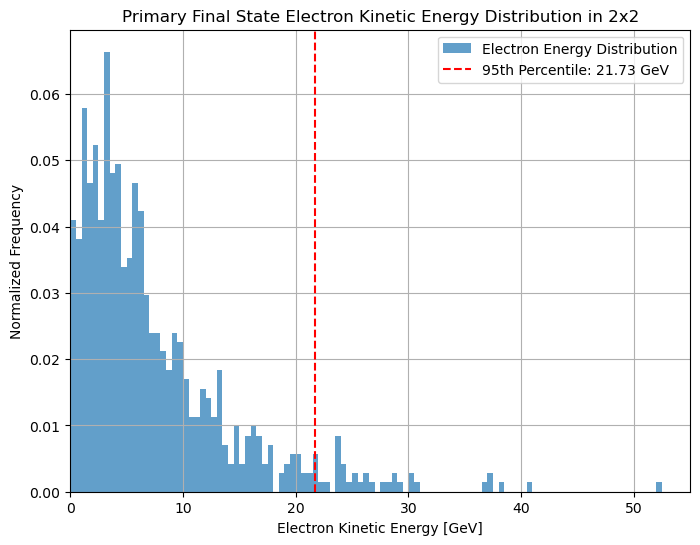

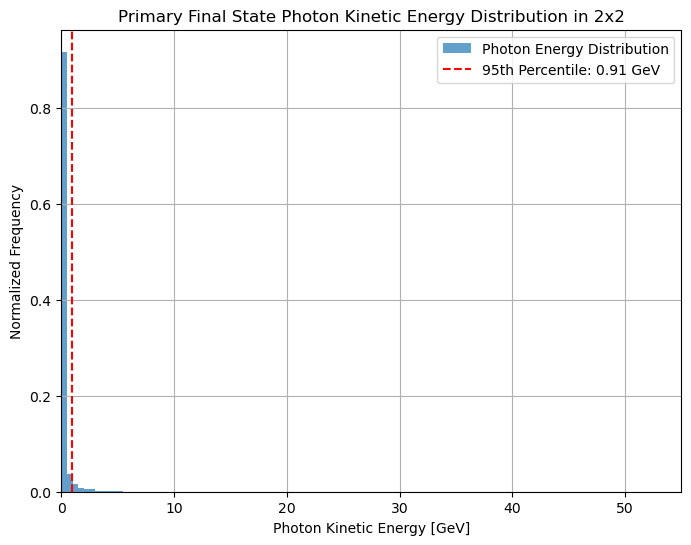

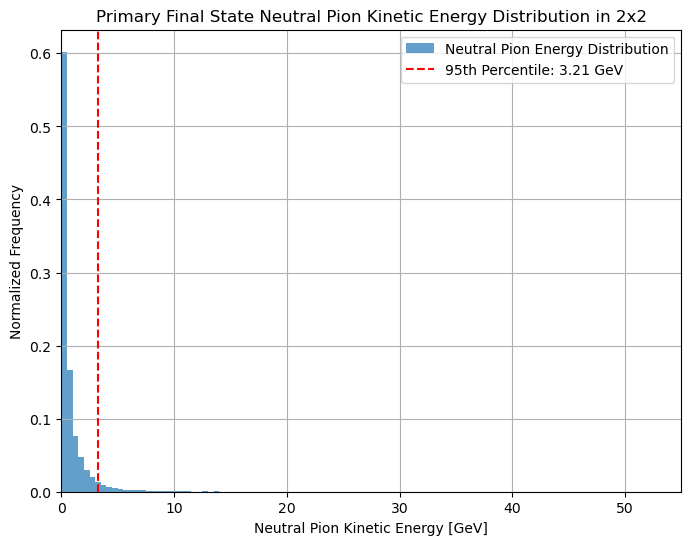

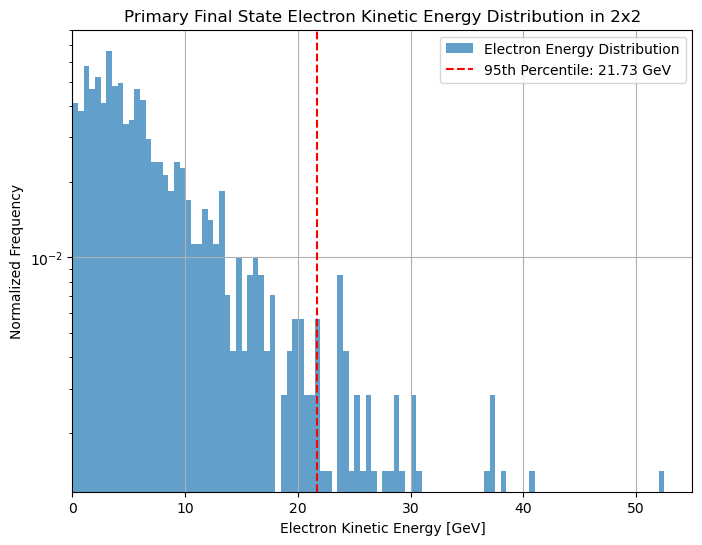

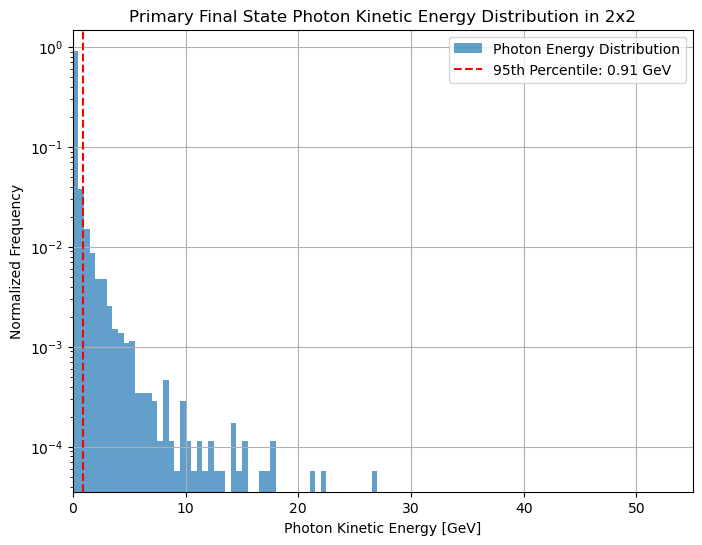

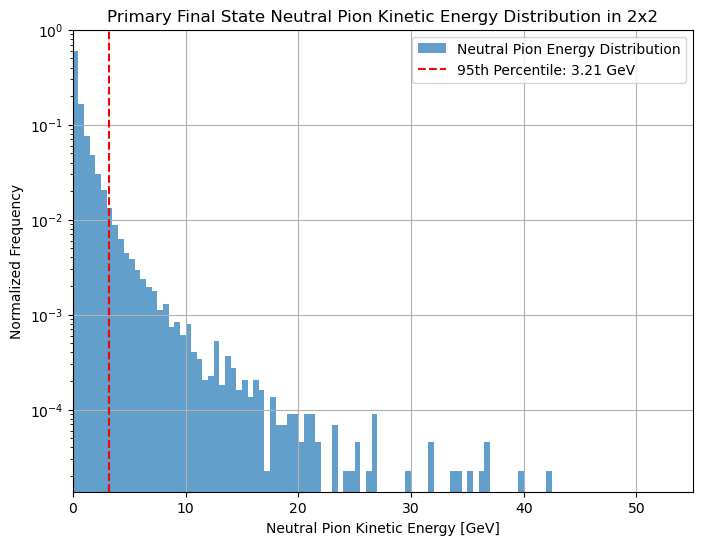

In [63]:
# Plot energy distributions in 2x2
energy_bins = np.linspace(0, 55, 111)  # Adjust the range and number of bins as needed

def make_energy_dist_plot(list_of_particle_energies, particle_type, bins, log_scale=False):

    plt.figure(figsize=(8, 6))
    counts, hist_bins = np.histogram(list_of_particle_energies/1000, bins=bins)
    plt.hist(hist_bins[:-1], bins=hist_bins, weights=counts/len(list_of_particle_energies), alpha=0.7, label=f'{particle_type} Energy Distribution')
    plt.xlabel(f'{particle_type} Kinetic Energy [GeV]')
    plt.ylabel('Normalized Frequency')
    plt.title(f'Primary Final State {particle_type} Kinetic Energy Distribution in 2x2')
    plt.legend()
    plt.grid(True)
    percentile_95 = np.percentile(list_of_particle_energies, 95)
    plt.axvline(percentile_95/1000, color='red', linestyle='--', label=f'95th Percentile: {percentile_95/1000:.2f} GeV')
    plt.legend()
    plt.xlim(0, 55)
    if log_scale==True:
        plt.yscale('log')
    plt.show()

make_energy_dist_plot(list_of_electron_energies, 'Electron', energy_bins)
make_energy_dist_plot(list_of_photon_energies, 'Photon', energy_bins)
make_energy_dist_plot(list_of_pi0_energies, 'Neutral Pion', energy_bins)

make_energy_dist_plot(list_of_electron_energies, 'Electron', energy_bins, log_scale=True)
make_energy_dist_plot(list_of_photon_energies, 'Photon', energy_bins, log_scale=True)
make_energy_dist_plot(list_of_pi0_energies, 'Neutral Pion', energy_bins, log_scale=True)


In [61]:
print("Max electron energy: ", np.max(list_of_electron_energies))
print("Max photon energy: ", np.max(list_of_photon_energies))
print("Max neutral pion energy: ", np.max(list_of_pi0_energies))

print("95th percentile electron energy: ", np.percentile(list_of_electron_energies, 95))
print("95th percentile photon energy: ", np.percentile(list_of_photon_energies, 95))
print("95th percentile neutral pion energy: ", np.percentile(list_of_pi0_energies, 95))

print("Number of primary final state electrons: ", len(list_of_electron_energies))
print("Number of primary final state photons: ", len(list_of_photon_energies))
print("Number of primary final state neutral pions: ", len(list_of_pi0_energies))

Max electron energy:  52385.6100948
Max photon energy:  26934.546875
Max neutral pion energy:  42425.39429375
95th percentile electron energy:  21730.472106518737
95th percentile photon energy:  909.0887268066402
95th percentile neutral pion energy:  3213.8504705078126
Number of primary final state electrons:  708
Number of primary final state photons:  17354
Number of primary final state neutral pions:  44051
